# Đọc Dataset GenImage Trên Kaggle

Notebook này dùng để đọc dataset **tiny genimage** 
Mục tiêu chính:

1. Tìm đúng thư mục dataset trong `/kaggle/input`.
2. Quét toàn bộ ảnh trong các subset như BigGAN, VQDM, SDV5, Wukong, ADM, GLIDE, Midjourney.
3. Tạo bảng index chứa đường dẫn ảnh và nhãn.
4. Tạo PyTorch `Dataset` và `DataLoader`.
5. Train thử một model nhỏ để kiểm tra pipeline đọc dữ liệu.

Quy ước label:

- `nature = 0`: ảnh thật.
- `ai = 1`: ảnh do AI sinh ra.


## 0. Cấu trúc dataset mong đợi

 dataset đang nằm ở:

```text
/kaggle/input/datasets/yangsangtai/tiny-genimage
```

Bên trong có dạng:

```text
tiny-genimage/
  imagenet_ai_0419_biggan/
    train/
      ai/
      nature/
    val/
      ai/
      nature/

  imagenet_ai_0419_vqdm/
  imagenet_ai_0424_sdv5/
  imagenet_ai_0424_wukong/
  imagenet_ai_0508_adm/
  imagenet_glide/
  imagenet_midjourney/
```

Nếu sau này Kaggle mount dataset sang path khác, chỉ cần sửa biến `MANUAL_DATASET_ROOT` ở cell bên dưới.

In [12]:
from pathlib import Path
import os
import random

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

INPUT_ROOT = Path('/kaggle/input')
WORKING_ROOT = Path('/kaggle/working')

print('INPUT_ROOT:', INPUT_ROOT)
print('WORKING_ROOT:', WORKING_ROOT)

print('\nCác thư mục cấp 1 trong /kaggle/input:')
for p in sorted(INPUT_ROOT.iterdir()):
    if p.is_dir():
        print(' -', p)


INPUT_ROOT: /kaggle/input
WORKING_ROOT: /kaggle/working

Các thư mục cấp 1 trong /kaggle/input:
 - /kaggle/input/datasets


## 1. Tìm đúng thư mục dataset

Cell này làm 2 việc:

1. Ưu tiên dùng path bạn đang có: `/kaggle/input/datasets/yangsangtai/tiny-genimage`.
2. Nếu path đó không đúng, tự quét đệ quy trong `/kaggle/input` để tìm folder chứa các subset `imagenet_ai_*`.

Nếu gặp lỗi `FileNotFoundError`, hãy kiểm tra lại dataset đã được Add vào notebook chưa, hoặc sửa `MANUAL_DATASET_ROOT`.

In [13]:
KNOWN_SUBSET_NAMES = {
    'imagenet_ai_0419_biggan',
    'imagenet_ai_0419_vqdm',
    'imagenet_ai_0424_sdv5',
    'imagenet_ai_0424_wukong',
    'imagenet_ai_0508_adm',
    'imagenet_glide',
    'imagenet_midjourney',
}

# Path đúng theo ảnh Kaggle bạn gửi.
# Nếu Kaggle đổi path, sửa dòng này.
MANUAL_DATASET_ROOT = Path('/kaggle/input/datasets/yangsangtai/tiny-genimage')

# Nếu muốn notebook tự tìm hoàn toàn, có thể đổi thành:
# MANUAL_DATASET_ROOT = None

def looks_like_genimage_root(path: Path) -> bool:
    """Kiểm tra một folder có phải root của tiny GenImage không."""
    if not path.exists() or not path.is_dir():
        return False
    try:
        child_names = {p.name for p in path.iterdir() if p.is_dir()}
    except PermissionError:
        return False
    return bool(child_names & KNOWN_SUBSET_NAMES)

def find_dataset_root(input_root: Path) -> Path:
    """Tìm folder chứa các subset imagenet_ai_* trong Kaggle input."""
    if MANUAL_DATASET_ROOT is not None:
        if looks_like_genimage_root(MANUAL_DATASET_ROOT):
            return MANUAL_DATASET_ROOT
        print('MANUAL_DATASET_ROOT không hợp lệ:', MANUAL_DATASET_ROOT)
        print('Notebook sẽ tự quét trong /kaggle/input...')

    # Kaggle đôi khi mount dataset sâu như /kaggle/input/datasets/user/dataset-name.
    for candidate in [input_root] + [p for p in input_root.rglob('*') if p.is_dir()]:
        if looks_like_genimage_root(candidate):
            return candidate

    print('Một số thư mục tìm thấy dưới /kaggle/input:')
    shown = 0
    for p in input_root.rglob('*'):
        if p.is_dir():
            print(' -', p)
            shown += 1
            if shown >= 100:
                break

    raise FileNotFoundError(
        'Không tìm thấy dataset GenImage. Hãy kiểm tra dataset đã được Add vào notebook chưa, '
        'hoặc sửa MANUAL_DATASET_ROOT cho đúng path.'
    )

DATASET_ROOT = find_dataset_root(INPUT_ROOT)

subset_dirs = sorted([
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir() and p.name in KNOWN_SUBSET_NAMES
])

print('DATASET_ROOT =', DATASET_ROOT)
print('\nCác subset tìm thấy:')
for p in subset_dirs:
    print(' -', p.name)
print('\nSố subset:', len(subset_dirs))


DATASET_ROOT = /kaggle/input/datasets/yangsangtai/tiny-genimage

Các subset tìm thấy:
 - imagenet_ai_0419_biggan
 - imagenet_ai_0419_vqdm
 - imagenet_ai_0424_sdv5
 - imagenet_ai_0424_wukong
 - imagenet_ai_0508_adm
 - imagenet_glide
 - imagenet_midjourney

Số subset: 7


## 2. Quét ảnh và tạo bảng index

Cell này quét các folder:

```text
<subset>/train/ai
<subset>/train/nature
<subset>/val/ai
<subset>/val/nature
```

Sau đó tạo bảng `df` gồm các cột:

- `path`: đường dẫn ảnh.
- `subset`: ảnh thuộc generator/subset nào.
- `split`: `train` hoặc `val`.
- `label_name`: `ai` hoặc `nature`.
- `label`: số label, trong đó `nature=0`, `ai=1`.

Bảng index cũng được lưu ra `/kaggle/working/genimage_index.csv` để bạn kiểm tra hoặc dùng lại.

In [14]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
LABEL_MAP = {'nature': 0, 'ai': 1}

records = []

for subset_dir in subset_dirs:
    for split in ['train', 'val']:
        for label_name, label_id in LABEL_MAP.items():
            folder = subset_dir / split / label_name
            if not folder.exists():
                print('Bỏ qua vì không tồn tại:', folder)
                continue

            for img_path in folder.rglob('*'):
                if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
                    records.append({
                        'path': str(img_path),
                        'subset': subset_dir.name,
                        'split': split,
                        'label_name': label_name,
                        'label': label_id,
                    })

df = pd.DataFrame(records)

print('Tổng số ảnh quét được:', len(df))
display(df.head())

print('\nThống kê số ảnh theo subset/split/label:')
display(df.groupby(['subset', 'split', 'label_name']).size().reset_index(name='count'))

index_path = WORKING_ROOT / 'genimage_index.csv'
df.to_csv(index_path, index=False)
print('\nĐã lưu file index tại:', index_path)


Tổng số ảnh quét được: 35000


,path,subset,split,label_name,label
0,/kaggle/input/datasets/yangsangtai/tiny-genima...,imagenet_ai_0419_biggan,train,nature,0
1,/kaggle/input/datasets/yangsangtai/tiny-genima...,imagenet_ai_0419_biggan,train,nature,0
2,/kaggle/input/datasets/yangsangtai/tiny-genima...,imagenet_ai_0419_biggan,train,nature,0
3,/kaggle/input/datasets/yangsangtai/tiny-genima...,imagenet_ai_0419_biggan,train,nature,0
4,/kaggle/input/datasets/yangsangtai/tiny-genima...,imagenet_ai_0419_biggan,train,nature,0



Thống kê số ảnh theo subset/split/label:


,subset,split,label_name,count
0,imagenet_ai_0419_biggan,train,ai,2000
1,imagenet_ai_0419_biggan,train,nature,2000
2,imagenet_ai_0419_biggan,val,ai,500
3,imagenet_ai_0419_biggan,val,nature,500
4,imagenet_ai_0419_vqdm,train,ai,2000
5,imagenet_ai_0419_vqdm,train,nature,2000
6,imagenet_ai_0419_vqdm,val,ai,500
7,imagenet_ai_0419_vqdm,val,nature,500
8,imagenet_ai_0424_sdv5,train,ai,2000
9,imagenet_ai_0424_sdv5,train,nature,2000



Đã lưu file index tại: /kaggle/working/genimage_index.csv


## 3. Chọn subset và giới hạn số ảnh để train thử

Dataset có nhiều subset. Để chạy nhẹ trước, notebook mặc định chỉ dùng:

```python
USE_SUBSETS = ['imagenet_ai_0419_biggan']
```

và giới hạn mỗi class tối đa 500 ảnh:

```python
LIMIT_PER_CLASS = 500
```

Gợi ý:

- Muốn train subset khác: đổi `USE_SUBSETS`.
- Muốn dùng nhiều subset: thêm tên vào list.
- Muốn dùng tất cả subset: đặt `USE_SUBSETS = None`.
- Muốn dùng hết ảnh: đặt `LIMIT_PER_CLASS = None`.

Ví dụ dùng tất cả subset nhưng vẫn giới hạn nhẹ:

```python
USE_SUBSETS = None
LIMIT_PER_CLASS = 1000
```

In [15]:
# Chọn subset muốn dùng để test pipeline.
USE_SUBSETS = ['imagenet_ai_0419_biggan']

# Nếu muốn dùng tất cả subset, đổi thành:
# USE_SUBSETS = None

# Giới hạn số ảnh mỗi class trong mỗi split.
# Để test nhanh nên giữ nhỏ trước.
LIMIT_PER_CLASS = 500

# Nếu muốn dùng hết ảnh, đổi thành:
# LIMIT_PER_CLASS = None

def make_work_df(df, use_subsets=None, limit_per_class=None, seed=42):
    work_df = df.copy()

    if use_subsets is not None:
        work_df = work_df[work_df['subset'].isin(use_subsets)].copy()

    if limit_per_class is not None:
        parts = []
        for (subset, split, label), part in work_df.groupby(['subset', 'split', 'label']):
            n = min(len(part), limit_per_class)
            parts.append(part.sample(n=n, random_state=seed))
        work_df = pd.concat(parts, ignore_index=True)

    return work_df.sample(frac=1, random_state=seed).reset_index(drop=True)

work_df = make_work_df(df, USE_SUBSETS, LIMIT_PER_CLASS)

train_df = work_df[work_df['split'] == 'train'].reset_index(drop=True)
val_df = work_df[work_df['split'] == 'val'].reset_index(drop=True)

print('Số ảnh đang dùng:', len(work_df))
print('Số ảnh train:', len(train_df))
print('Số ảnh val:', len(val_df))

display(work_df.groupby(['subset', 'split', 'label_name']).size().reset_index(name='count'))


Số ảnh đang dùng: 2000
Số ảnh train: 1000
Số ảnh val: 1000


,subset,split,label_name,count
0,imagenet_ai_0419_biggan,train,ai,500
1,imagenet_ai_0419_biggan,train,nature,500
2,imagenet_ai_0419_biggan,val,ai,500
3,imagenet_ai_0419_biggan,val,nature,500


## 4. Xem thử vài ảnh

Cell này giúp kiểm tra nhanh:

- Đường dẫn ảnh có đọc được không.
- Ảnh có đúng label `ai` hoặc `nature` không.
- Dataset có bị lỗi ảnh không.


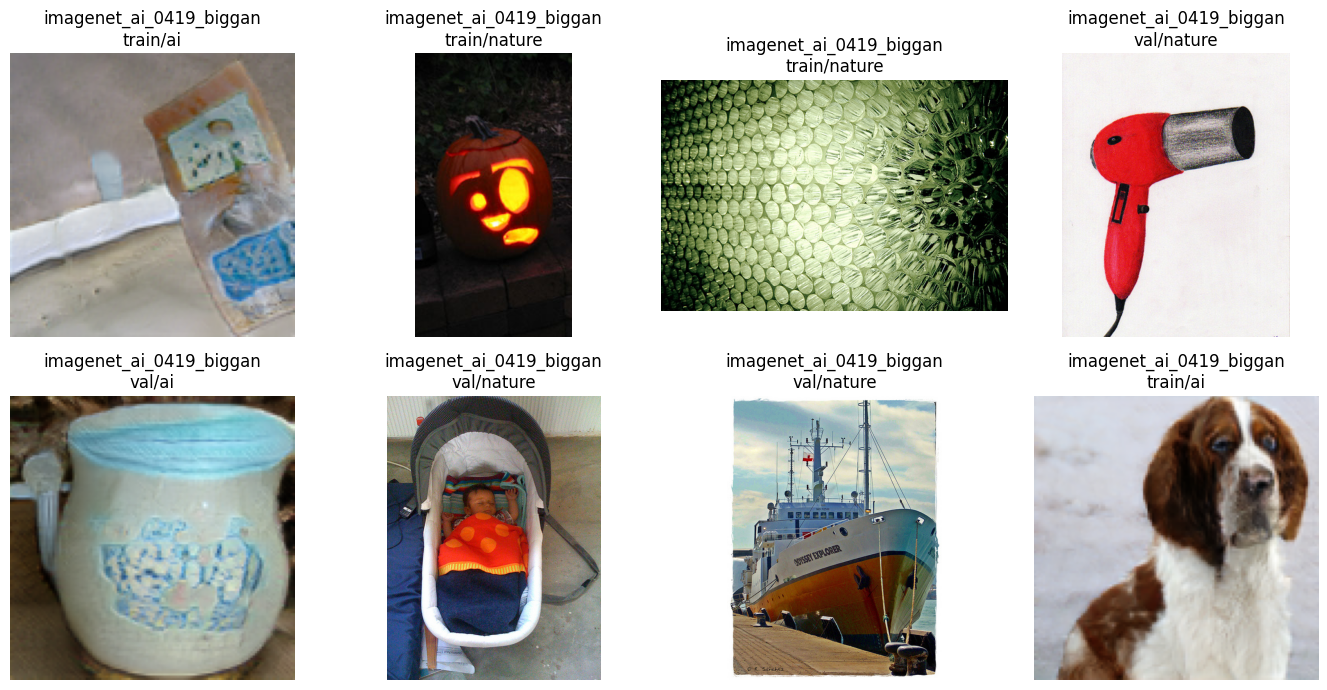

In [16]:
sample_df = work_df.sample(n=min(8, len(work_df)), random_state=7)

plt.figure(figsize=(14, 7))
for i, row in enumerate(sample_df.itertuples(), start=1):
    img = Image.open(row.path).convert('RGB')
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(f'{row.subset}\n{row.split}/{row.label_name}')
    plt.axis('off')
plt.tight_layout()
plt.show()


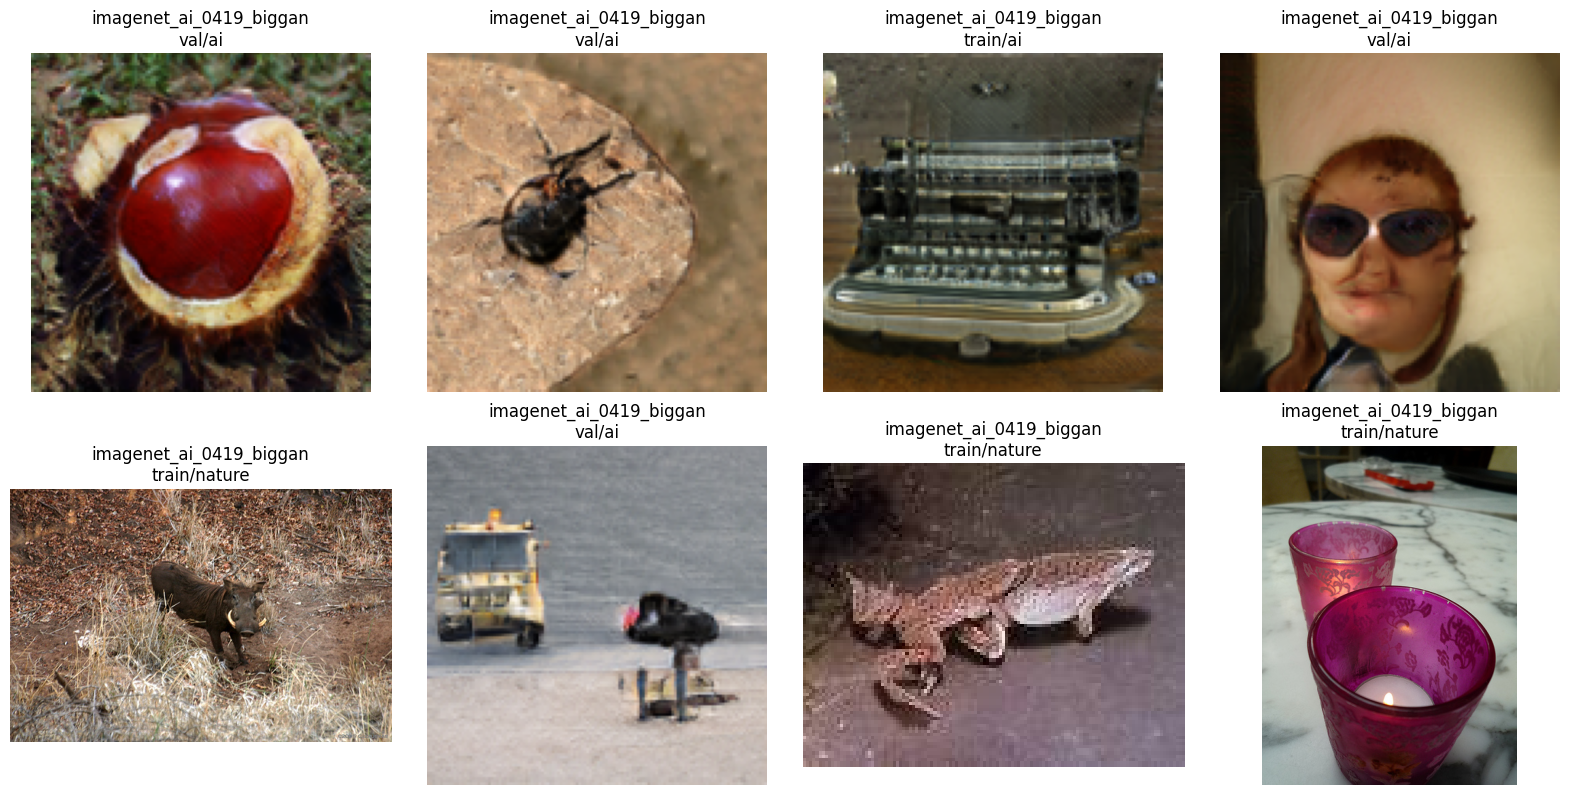

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Lấy ngẫu nhiên 8 ảnh từ data đang dùng
sample_df = work_df.sample(n=8, random_state=42)

plt.figure(figsize=(16, 8))

for i, row in enumerate(sample_df.itertuples(), start=1):
    img = Image.open(row.path).convert("RGB")

    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(f"{row.subset}\n{row.split}/{row.label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

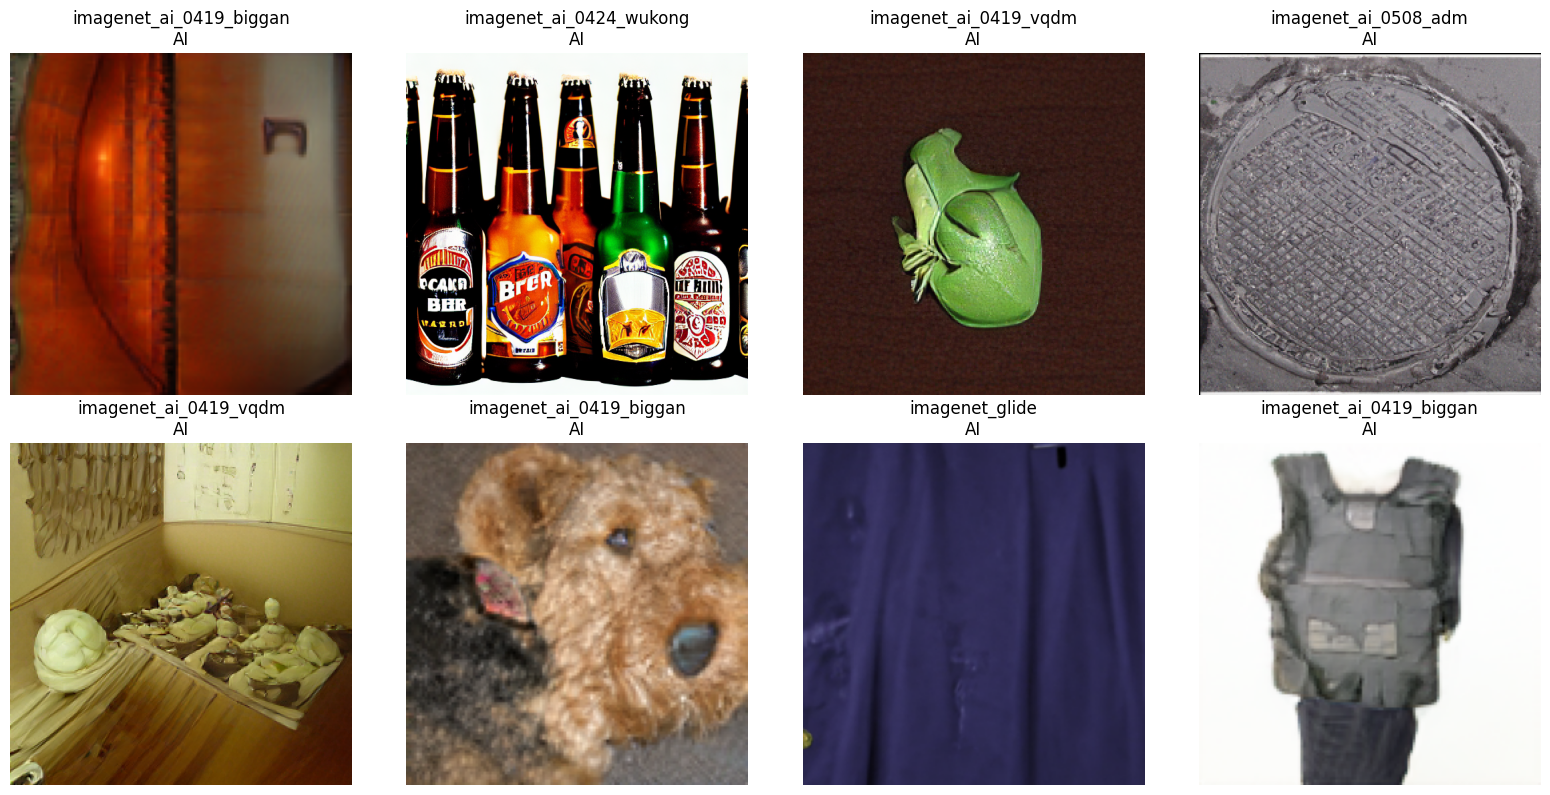

In [23]:
ai_df = df[df["label_name"] == "ai"]

sample_df = ai_df.sample(n=8, random_state=42)

plt.figure(figsize=(16, 8))

for i, row in enumerate(sample_df.itertuples(), start=1):
    img = Image.open(row.path).convert("RGB")

    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.title(f"{row.subset}\nAI")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Phân tích dữ liệu

`GenImageDataset` sẽ đọc ảnh từ cột `path` trong dataframe.

Transform đang dùng:

- Resize ảnh về `224 x 224`.
- Train có random horizontal flip.
- Chuẩn hóa theo mean/std ImageNet.

Output mỗi sample:

```python
image, label
```

Trong đó:

- `image`: tensor shape `[3, 224, 224]`.
- `label`: `0` hoặc `1`.


In [24]:
from PIL import Image
from tqdm.auto import tqdm

sizes = []

for path in tqdm(df["path"]):
    img = Image.open(path)
    sizes.append(img.size)

df["width"] = [s[0] for s in sizes]
df["height"] = [s[1] for s in sizes]

display(df[["width", "height"]].describe())
display(df.groupby(["subset", "label_name"])[["width", "height"]].describe())

  0%|          | 0/35000 [00:00<?, ?it/s]

,width,height
count,35000.000000,35000.000000
mean,448.385743,415.260200
std,246.113742,233.093531
min,34.000000,38.000000
25%,256.000000,256.000000
50%,500.000000,375.000000
75%,512.000000,500.000000
max,4786.000000,4419.000000


width                                \
                                     count       mean         std    min   
subset                  label_name                                         
imagenet_ai_0419_biggan ai          2500.0   128.0000    0.000000  128.0   
                        nature      2500.0   476.7992  200.035182   49.0   
imagenet_ai_0419_vqdm   ai          2500.0   256.0000    0.000000  256.0   
                        nature      2500.0   477.8968  204.342063   53.0   
imagenet_ai_0424_sdv5   ai          2500.0   512.0000    0.000000  512.0   
                        nature      2500.0   474.5520  195.132040   34.0   
imagenet_ai_0424_wukong ai          2500.0   512.0000    0.000000  512.0   
                        nature      2500.0   473.7012  211.393113   60.0   
imagenet_ai_0508_adm    ai          2500.0   256.0000    0.000000  256.0   
                        nature      2500.0   482.6224  201.387154   63.0   
imagenet_glide          ai          2500.0   256.0000    0.000000  256.0   
                        nature      2500.0   475.5076  203.046417   51.0   
imagenet_midjourney     ai          2500.0  1023.7952   10.240000  512.0   
                        nature      2500.0   472.5260  208.107645   48.0   

                                                                     height  \
                                        25%     50%     75%     max   count   
subset                  label_name                                            
imagenet_ai_0419_biggan ai           128.00   128.0   128.0   128.0  2500.0   
                        nature       375.00   500.0   500.0  3072.0  2500.0   
imagenet_ai_0419_vqdm   ai           256.00   256.0   256.0   256.0  2500.0   
                        nature       375.00   500.0   500.0  3200.0  2500.0   
imagenet_ai_0424_sdv5   ai           512.00   512.0   512.0   512.0  2500.0   
                        nature       375.00   500.0   500.0  2848.0  2500.0   
imagenet_ai_0424_wukong ai           512.00   512.0   512.0   512.0  2500.0   
                        nature       375.00   500.0   500.0  4786.0  2500.0   
imagenet_ai_0508_adm    ai           256.00   256.0   256.0   256.0  2500.0   
                        nature       390.75   500.0   500.0  3072.0  2500.0   
imagenet_glide          ai           256.00   256.0   256.0   256.0  2500.0   
                        nature       375.00   500.0   500.0  2958.0  2500.0   
imagenet_midjourney     ai          1024.00  1024.0  1024.0  1024.0  2500.0   
                        nature       375.00   500.0   500.0  4272.0  2500.0   

                                                                          \
                                         mean         std    min     25%   
subset                  label_name                                         
imagenet_ai_0419_biggan ai           128.0000    0.000000  128.0   128.0   
                        nature       409.3544  164.939241   42.0   334.0   
imagenet_ai_0419_vqdm   ai           256.0000    0.000000  256.0   256.0   
                        nature       408.6424  174.336201   49.0   334.0   
imagenet_ai_0424_sdv5   ai           512.0000    0.000000  512.0   512.0   
                        nature       408.3252  159.796886   60.0   334.0   
imagenet_ai_0424_wukong ai           512.0000    0.000000  512.0   512.0   
                        nature       411.1824  177.470925   50.0   334.0   
imagenet_ai_0508_adm    ai           256.0000    0.000000  256.0   256.0   
                        nature       415.1132  198.654785   57.0   334.0   
imagenet_glide          ai           256.0000    0.000000  256.0   256.0   
                        nature       410.6060  179.099377   63.0   334.0   
imagenet_midjourney     ai          1023.7952   10.240000  512.0  1024.0   
                        nature       406.6240  162.984574   38.0   334.0   

                                                            
                                       50%    

# Đánh Giá Kích Thước Ảnh Trong Dataset GenImage

## 1. Tổng Quan

Dataset hiện tại gồm 7 subset:

- `imagenet_ai_0419_biggan`
- `imagenet_ai_0419_vqdm`
- `imagenet_ai_0424_sdv5`
- `imagenet_ai_0424_wukong`
- `imagenet_ai_0508_adm`
- `imagenet_glide`
- `imagenet_midjourney`

Mỗi subset có hai nhóm ảnh:

- `ai`: ảnh do mô hình AI sinh ra.
- `nature`: ảnh thật từ ImageNet.

Mỗi nhóm có 2500 ảnh, gồm:

- 2000 ảnh train.
- 500 ảnh validation.

---

## 2. Bảng Thống Kê Kích Thước Ảnh

| Subset | Label | Số ảnh | Width mean ± std | Width min-max | Height mean ± std | Height min-max |
|---|---:|---:|---:|---:|---:|---:|
| biggan | ai | 2500 | 128.0 ± 0.0 | 128-128 | 128.0 ± 0.0 | 128-128 |
| biggan | nature | 2500 | 476.8 ± 200.0 | 49-3072 | 409.4 ± 164.9 | 42-2112 |
| vqdm | ai | 2500 | 256.0 ± 0.0 | 256-256 | 256.0 ± 0.0 | 256-256 |
| vqdm | nature | 2500 | 477.9 ± 204.3 | 53-3200 | 408.6 ± 174.3 | 49-3484 |
| sdv5 | ai | 2500 | 512.0 ± 0.0 | 512-512 | 512.0 ± 0.0 | 512-512 |
| sdv5 | nature | 2500 | 474.6 ± 195.1 | 34-2848 | 408.3 ± 159.8 | 60-2362 |
| wukong | ai | 2500 | 512.0 ± 0.0 | 512-512 | 512.0 ± 0.0 | 512-512 |
| wukong | nature | 2500 | 473.7 ± 211.4 | 60-4786 | 411.2 ± 177.5 | 50-4419 |
| adm | ai | 2500 | 256.0 ± 0.0 | 256-256 | 256.0 ± 0.0 | 256-256 |
| adm | nature | 2500 | 482.6 ± 201.4 | 63-3072 | 415.1 ± 198.7 | 57-3888 |
| glide | ai | 2500 | 256.0 ± 0.0 | 256-256 | 256.0 ± 0.0 | 256-256 |
| glide | nature | 2500 | 475.5 ± 203.0 | 51-2958 | 410.6 ± 179.1 | 63-3872 |
| midjourney | ai | 2500 | 1023.8 ± 10.2 | 512-1024 | 1023.8 ± 10.2 | 512-1024 |
| midjourney | nature | 2500 | 472.5 ± 208.1 | 48-4272 | 406.6 ± 163.0 | 38-2848 |

---

## 3. Nhận Xét Chính

Từ bảng thống kê, có thể thấy ảnh AI và ảnh nature có sự khác biệt rất lớn về kích thước.

Ảnh AI gần như có kích thước cố định theo từng generator:

| Generator | Kích thước ảnh AI |
|---|---:|
| BigGAN | 128 × 128 |
| VQDM | 256 × 256 |
| ADM | 256 × 256 |
| GLIDE | 256 × 256 |
| Stable Diffusion V5 | 512 × 512 |
| Wukong | 512 × 512 |
| Midjourney | chủ yếu 1024 × 1024 |

Trong khi đó, ảnh `nature` có kích thước đa dạng hơn rất nhiều. Trung bình ảnh nature có:

```text
Width  ≈ 470-480
Height ≈ 406-415